In [ ]:
#pip install -q rasterio matplotlib numpy opencv-python torch torchvision pandas scikit-learn pyspark


In [3]:
import os
import glob
import json
import numpy as np
import pandas as pd
import rasterio
import numpy as np
from pyspark.sql.functions import col, udf
from pyspark.sql.types import ArrayType, IntegerType, FloatType



In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
# Copy the single archive part and extract it into the target directory
!cp "/content/drive/MyDrive/DA_dataset/xview2_geotiff.tgz.part-aa" /content/xview2_geotiff.tgz

# Verify the size of the copied archive file
!ls -lh /content/xview2_geotiff.tgz

!mkdir -p /content/xview2_part_aa/
!tar -xzf /content/xview2_geotiff.tgz -C /content/xview2_part_aa/

# Verify extraction by listing the contents of the new directory
!ls -la /content/xview2_part_aa/

-rw------- 1 root root 9.8G Apr  3 17:52 /content/xview2_geotiff.tgz

gzip: stdin: unexpected end of file
tar: Unexpected EOF in archive
tar: Unexpected EOF in archive
tar: Error is not recoverable: exiting now
total 12
drwxr-xr-x 3 root root 4096 Apr  3 17:52 .
drwxr-xr-x 1 root root 4096 Apr  3 17:52 ..
drwxrwxr-x 5 1007 1007 4096 Aug  2  2020 geotiffs


In [ ]:
# size 
!ls -lh "/content/drive/MyDrive/DA_dataset/xview2_geotiff.tgz.part-aa"

-rw------- 1 root root 9.8G Feb 14 18:24 /content/drive/MyDrive/DA_dataset/xview2_geotiff.tgz.part-aa


In [ ]:
import glob

BASE_PATH = "/content/xview2_part_aa/geotiffs"

# structure 
!find /content/xview2_part_aa/geotiffs/ -type d

/content/xview2_part_aa/geotiffs/
/content/xview2_part_aa/geotiffs/tier1
/content/xview2_part_aa/geotiffs/tier1/images
/content/xview2_part_aa/geotiffs/test
/content/xview2_part_aa/geotiffs/test/labels
/content/xview2_part_aa/geotiffs/test/images
/content/xview2_part_aa/geotiffs/hold
/content/xview2_part_aa/geotiffs/hold/labels
/content/xview2_part_aa/geotiffs/hold/images


In [7]:
import os
import glob

BASE_PATH = "/content/xview2_part_aa/geotiffs/hold"

IMG_DIR = os.path.join(BASE_PATH, "images")
LBL_DIR = os.path.join(BASE_PATH, "labels")

imgs = sorted(glob.glob(os.path.join(IMG_DIR, "*.tif")))
lbls = sorted(glob.glob(os.path.join(LBL_DIR, "*.json")))

print(f"Images found: {len(imgs)}")
print(f"Labels found: {len(lbls)}")
print("Image dir exists:", os.path.exists(IMG_DIR))
print("Label dir exists:", os.path.exists(LBL_DIR))

Images found: 1866
Labels found: 1866
Image dir exists: True
Label dir exists: True


In [8]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("xBD_Multivariate_Analysis") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

print("Spark version:", spark.version)


Spark version: 4.0.2


In [9]:
post_image_paths = sorted([
    p for p in glob.glob(os.path.join(IMG_DIR, "*.tif"))
    if "_post_disaster" in os.path.basename(p)
])

print("Total post-disaster images:", len(post_image_paths))
print("Example image:", os.path.basename(post_image_paths[0]))


Total post-disaster images: 933
Example image: guatemala-volcano_00000004_post_disaster.tif


In [10]:
df_images = spark.createDataFrame(
    [(p, os.path.basename(p)) for p in post_image_paths],
    ["image_path", "image_name"]
)

df_images.show(5, truncate=False)
print("Spark image count:", df_images.count())


+-----------------------------------------------------------------------------------------+--------------------------------------------+
|image_path                                                                               |image_name                                  |
+-----------------------------------------------------------------------------------------+--------------------------------------------+
|/content/xview2_part_aa/geotiffs/hold/images/guatemala-volcano_00000004_post_disaster.tif|guatemala-volcano_00000004_post_disaster.tif|
|/content/xview2_part_aa/geotiffs/hold/images/guatemala-volcano_00000012_post_disaster.tif|guatemala-volcano_00000012_post_disaster.tif|
|/content/xview2_part_aa/geotiffs/hold/images/guatemala-volcano_00000014_post_disaster.tif|guatemala-volcano_00000014_post_disaster.tif|
|/content/xview2_part_aa/geotiffs/hold/images/guatemala-volcano_00000020_post_disaster.tif|guatemala-volcano_00000020_post_disaster.tif|
|/content/xview2_part_aa/geotiffs/hold/im

In [11]:
from pyspark.sql.functions import regexp_replace

# Load label filenames into Spark
df_labels = spark.createDataFrame(
    [(f,) for f in os.listdir(LBL_DIR) if f.endswith(".json")],
    ["label_file"]
)

# Normalize image names: remove ONLY extension
df_images_norm = df_images.withColumn(
    "base_id",
    regexp_replace("image_name", ".tif", "")
)

# Normalize label names: remove ONLY extension
df_labels_norm = df_labels.withColumn(
    "base_id",
    regexp_replace("label_file", ".json", "")
)

# Join on correct base_id
df_images_clean = df_images_norm.join(
    df_labels_norm,
    on="base_id",
    how="inner"
).cache()

print("Usable images with labels:", df_images_clean.count())
df_images_clean.select("base_id", "image_name").show(5, truncate=False)


Usable images with labels: 933
+-----------------------------------------+---------------------------------------------+
|base_id                                  |image_name                                   |
+-----------------------------------------+---------------------------------------------+
|hurricane-florence_00000257_post_disaster|hurricane-florence_00000257_post_disaster.tif|
|midwest-flooding_00000296_post_disaster  |midwest-flooding_00000296_post_disaster.tif  |
|palu-tsunami_00000052_post_disaster      |palu-tsunami_00000052_post_disaster.tif      |
|socal-fire_00000924_post_disaster        |socal-fire_00000924_post_disaster.tif        |
|hurricane-harvey_00000074_post_disaster  |hurricane-harvey_00000074_post_disaster.tif  |
+-----------------------------------------+---------------------------------------------+
only showing top 5 rows


# step 2


In [12]:
def load_geotiff_rgb(path):
    with rasterio.open(path) as src:
        img = src.read([1, 2, 3])  # (3, H, W)
        nodata = src.nodata

    img = img.transpose(1, 2, 0).astype(np.float32)  # (H, W, 3)

    if nodata is not None:
        mask = np.any(img != nodata, axis=2)
    else:
        mask = np.any(img > 0, axis=2)

    if mask.any():
        img[mask] /= (img[mask].max() + 1e-6)

    img[~mask] = 0.0
    return img, mask


def crop_to_valid(img, mask):
    if not mask.any():
        return img

    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)

    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    return img[rmin:rmax+1, cmin:cmax+1]


In [13]:
def preprocessing_summary(image_path):
    img, mask = load_geotiff_rgb(image_path)
    img_crop = crop_to_valid(img, mask)

    h, w, _ = img_crop.shape
    valid_ratio = float(mask.sum() / mask.size) if mask.size > 0 else 0.0

    return int(h), int(w), valid_ratio


In [14]:
from pyspark.sql.types import StructType, StructField, IntegerType, FloatType

schema = StructType([
    StructField("crop_h", IntegerType(), False),
    StructField("crop_w", IntegerType(), False),
    StructField("valid_ratio", FloatType(), False)
])

preprocess_udf = udf(preprocessing_summary, schema)

In [15]:
df_pre = df_images_clean.withColumn(
    "prep",
    preprocess_udf(col("image_path"))
).select(
    "*",
    col("prep.crop_h"),
    col("prep.crop_w"),
    col("prep.valid_ratio")
).drop("prep").cache()

print("Preprocessed samples:", df_pre.count())
df_pre.select("image_name", "crop_h", "crop_w", "valid_ratio").show(5, truncate=False)


Preprocessed samples: 933
+---------------------------------------------+------+------+-----------+
|image_name                                   |crop_h|crop_w|valid_ratio|
+---------------------------------------------+------+------+-----------+
|hurricane-florence_00000257_post_disaster.tif|1024  |1024  |1.0        |
|midwest-flooding_00000296_post_disaster.tif  |1024  |1024  |1.0        |
|palu-tsunami_00000052_post_disaster.tif      |1024  |1024  |1.0        |
|socal-fire_00000924_post_disaster.tif        |1024  |1024  |1.0        |
|hurricane-harvey_00000074_post_disaster.tif  |1024  |1024  |1.0        |
+---------------------------------------------+------+------+-----------+
only showing top 5 rows


In [16]:
df_pre.selectExpr(
    "min(valid_ratio) as min_valid",
    "avg(valid_ratio) as avg_valid",
    "max(valid_ratio) as max_valid"
).show()


+---------+---------+---------+
|min_valid|avg_valid|max_valid|
+---------+---------+---------+
|      1.0|      1.0|      1.0|
+---------+---------+---------+



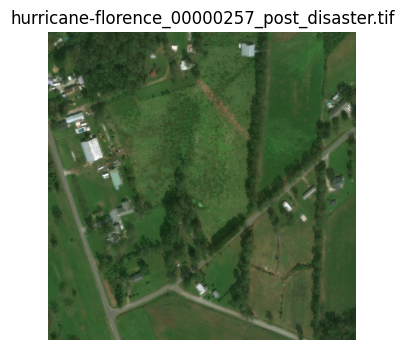

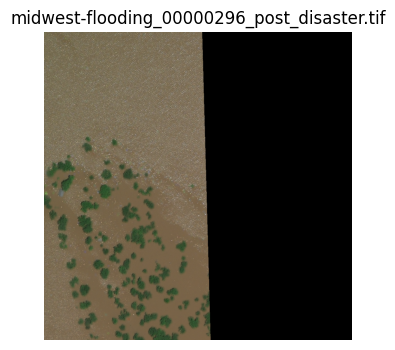

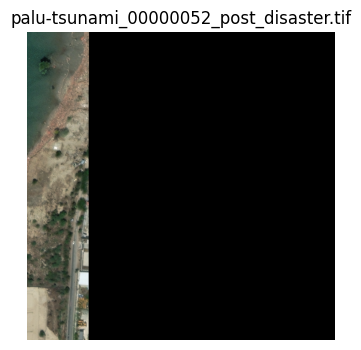

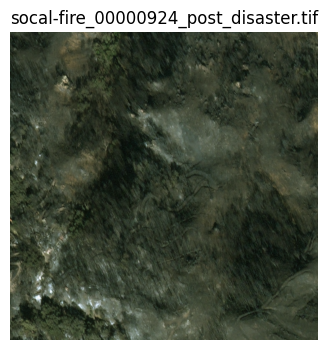

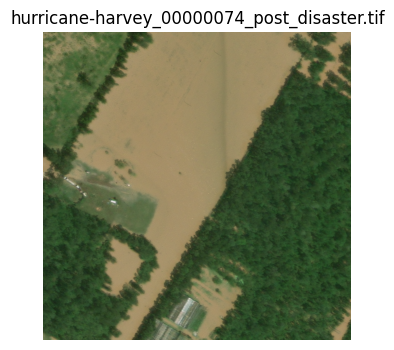

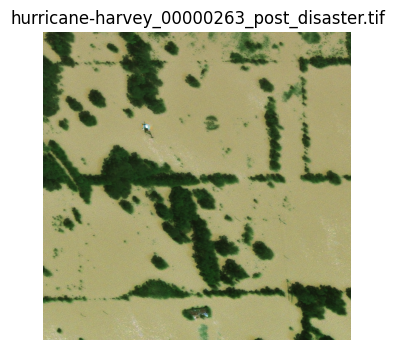

In [17]:
import matplotlib.pyplot as plt

def visualize_multiple_images(image_paths, max_images=6):
    for img_path in image_paths[:max_images]:
        img, mask = load_geotiff_rgb(img_path)
        img_crop = crop_to_valid(img, mask)

        plt.figure(figsize=(4,4))
        plt.imshow(img_crop)
        plt.title(os.path.basename(img_path))
        plt.axis("off")
        plt.show()

sample_paths = (
    df_pre.select("image_path")
    .limit(6)
    .rdd.map(lambda r: r[0])
    .collect()
)

visualize_multiple_images(sample_paths, max_images=6)


# step 3

In [18]:
def extract_resnet50_feature(image_path):
    import torch
    import torch.nn as nn
    from torchvision import models, transforms

    # Load pretrained ResNet-50 and remove final classification layer
    resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    resnet = nn.Sequential(*list(resnet.children())[:-1])
    resnet.eval()

    # ImageNet preprocessing
    tfm = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    # Use your preprocessing functions from Step 2
    img, mask = load_geotiff_rgb(image_path)
    img = crop_to_valid(img, mask)

    x = tfm(img).unsqueeze(0)  # (1,3,224,224)

    with torch.no_grad():
        feat = resnet(x)  # (1,2048,1,1)

    return feat.squeeze().numpy().astype(float).tolist()


In [19]:
from pyspark.sql.functions import col, udf
from pyspark.sql.types import ArrayType, FloatType

feat_udf = udf(extract_resnet50_feature, ArrayType(FloatType()))

df_feat = df_pre.withColumn("features", feat_udf(col("image_path"))).cache()

print("Rows with extracted features:", df_feat.count())
df_feat.select("image_name", "features").show(2, truncate=70)


Rows with extracted features: 933
+---------------------------------------------+----------------------------------------------------------------------+
|                                   image_name|                                                              features|
+---------------------------------------------+----------------------------------------------------------------------+
|hurricane-florence_00000257_post_disaster.tif|[0.42273444, 0.4968497, 0.32928658, 1.1742079, 0.1860046, 0.3357990...|
|  midwest-flooding_00000296_post_disaster.tif|[0.07685818, 0.16800742, 0.26524973, 0.07825259, 1.6936232, 0.43349...|
+---------------------------------------------+----------------------------------------------------------------------+
only showing top 2 rows


In [20]:
first_len = df_feat.selectExpr("size(features) as n").limit(1).collect()[0]["n"]
print("Feature length:", first_len)


Feature length: 2048


In [21]:
import numpy as np

features = np.array(
    df_feat.select("features").rdd.map(lambda r: r[0]).collect(),
    dtype=np.float32
)

image_names = df_feat.select("image_name").rdd.map(lambda r: r[0]).collect()

print("Feature matrix shape:", features.shape)
print("Example first 5 values:", features[0][:5])


Feature matrix shape: (933, 2048)
Example first 5 values: [0.42273444 0.4968497  0.32928658 1.1742079  0.1860046 ]


In [22]:
import pandas as pd

meta_df = df_feat.select("image_path", "image_name", "base_id", "crop_h", "crop_w", "valid_ratio") \
                 .toPandas()

np.save("features_resnet50.npy", features)
meta_df.to_csv("meta_step3.csv", index=False)

print("Saved: features_resnet50.npy, meta_step3.csv")


Saved: features_resnet50.npy, meta_step3.csv


# step 4

In [ ]:
import json
import glob
import os

label_paths = glob.glob(os.path.join(LBL_DIR, "*.json"))

label_map = {
    os.path.splitext(os.path.basename(p))[0]: p
    for p in label_paths
}

print("Total label JSONs indexed:", len(label_map))


Total label JSONs indexed: 1866


In [ ]:
SEVERITY_ORDER = {
    "no-damage": 0,
    "minor-damage": 1,
    "major-damage": 2,
    "destroyed": 3
}


In [ ]:
def parse_xbd_label(json_path):
    with open(json_path, "r") as f:
        data = json.load(f)

    # Disaster metadata (may be None for some files)
    metadata = data.get("metadata", {})
    disaster = metadata.get("disaster", metadata.get("disaster_type", None))

    # Extract building-level damage
    features = data.get("features", {}).get("xy", [])
    damage_levels = []

    for feat in features:
        props = feat.get("properties", {})
        dmg = props.get("damage_type", props.get("subtype", None))
        if dmg in SEVERITY_ORDER:
            damage_levels.append(dmg)

    if len(damage_levels) == 0:
        return None, disaster

    # Image-level severity = max observed severity
    image_severity = max(damage_levels, key=lambda x: SEVERITY_ORDER[x])
    return image_severity, disaster


In [ ]:
rows = []

for idx, img_name in enumerate(image_names):
    base_id = img_name.replace(".tif", "")
    json_path = label_map.get(base_id, None)

    if json_path is None:
        continue

    severity, disaster = parse_xbd_label(json_path)

    if severity is None:
        continue

    rows.append({
        "image_name": img_name,
        "base_id": base_id,
        "severity": severity,
        "severity_code": SEVERITY_ORDER[severity],
        "disaster": disaster,
        "feature_index": idx
    })

analysis_df = pd.DataFrame(rows)

print("Final analysis samples:", len(analysis_df))
analysis_df.head()


Final analysis samples: 751


,image_name,base_id,severity,severity_code,disaster,feature_index
0,hurricane-florence_00000257_post_disaster.tif,hurricane-florence_00000257_post_disaster,no-damage,0,hurricane-florence,0
1,midwest-flooding_00000296_post_disaster.tif,midwest-flooding_00000296_post_disaster,destroyed,3,midwest-flooding,1
2,palu-tsunami_00000052_post_disaster.tif,palu-tsunami_00000052_post_disaster,destroyed,3,palu-tsunami,2
3,hurricane-harvey_00000074_post_disaster.tif,hurricane-harvey_00000074_post_disaster,minor-damage,1,hurricane-harvey,4
4,hurricane-harvey_00000263_post_disaster.tif,hurricane-harvey_00000263_post_disaster,major-damage,2,hurricane-harvey,5


In [ ]:
print("Severity distribution:")
print(analysis_df["severity"].value_counts())

print("\nDisaster distribution (top 5):")
print(analysis_df["disaster"].value_counts().head())


Severity distribution:
severity
destroyed       332
no-damage       240
major-damage    115
minor-damage     64
Name: count, dtype: int64

Disaster distribution (top 5):
disaster
socal-fire            126
hurricane-florence    110
hurricane-michael     106
hurricane-harvey       92
hurricane-matthew      88
Name: count, dtype: int64


In [ ]:
X = features[analysis_df["feature_index"].values]
y_severity = analysis_df["severity_code"].values
y_disaster = analysis_df["disaster"].fillna("unknown").values

print("X aligned shape:", X.shape)


X aligned shape: (751, 2048)


# step 5

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Standardize
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=min(100, X_std.shape[1]), random_state=42)
Z = pca.fit_transform(X_std)

print("Z shape:", Z.shape)


Z shape: (751, 100)


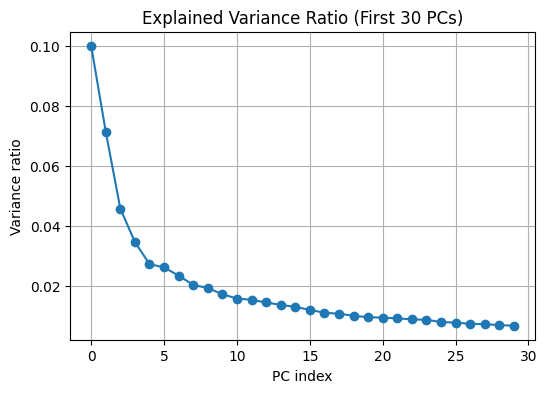

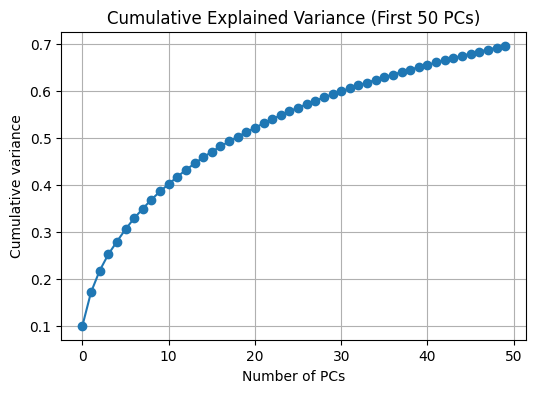

Cumulative variance @ 5 PCs: 0.279
Cumulative variance @ 10 PCs: 0.385
Cumulative variance @ 20 PCs: 0.512
Cumulative variance @ 50 PCs: 0.695


In [ ]:
expl = pca.explained_variance_ratio_
cum_expl = np.cumsum(expl)

plt.figure(figsize=(6,4))
plt.plot(expl[:30], marker="o")
plt.title("Explained Variance Ratio (First 30 PCs)")
plt.xlabel("PC index")
plt.ylabel("Variance ratio")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(cum_expl[:50], marker="o")
plt.title("Cumulative Explained Variance (First 50 PCs)")
plt.xlabel("Number of PCs")
plt.ylabel("Cumulative variance")
plt.grid(True)
plt.show()

# quick numeric summary
for k in [5, 10, 20, 50]:
    if k <= len(cum_expl):
        print(f"Cumulative variance @ {k} PCs: {cum_expl[k-1]:.3f}")


In [ ]:
from sklearn.metrics import pairwise_distances

# use first N PCs (stable + fast)
NPCS = 20
Zk = Z[:, :NPCS]

D = pairwise_distances(Zk, metric="euclidean")

labels = y_severity  # severity codes

intra = []
inter = []
n = len(labels)

for i in range(n):
    for j in range(i+1, n):
        if labels[i] == labels[j]:
            intra.append(D[i, j])
        else:
            inter.append(D[i, j])

intra_mean = float(np.mean(intra))
inter_mean = float(np.mean(inter))
ratio = intra_mean / inter_mean

print("Severity intra-distance mean:", intra_mean)
print("Severity inter-distance mean:", inter_mean)
print("Intra/Inter ratio (lower is better):", ratio)


Severity intra-distance mean: 44.1500129699707
Severity inter-distance mean: 44.956626892089844
Intra/Inter ratio (lower is better): 0.9820579527895794


In [ ]:
from sklearn.metrics import silhouette_score

sil_sev = silhouette_score(Zk, y_severity, metric="euclidean")
print("Silhouette score (severity):", float(sil_sev))


Silhouette score (severity): -0.015557236969470978


In [ ]:
from sklearn.preprocessing import LabelEncoder

dis_enc = LabelEncoder()
y_disaster_code = dis_enc.fit_transform(y_disaster)

sil_dis = silhouette_score(Zk, y_disaster_code, metric="euclidean")
print("Silhouette score (disaster):", float(sil_dis))

print("\nIf silhouette(disaster) > silhouette(severity),")
print("then disaster type is a stronger organizing factor than severity labels.")


Silhouette score (disaster): 0.011845388449728489

If silhouette(disaster) > silhouette(severity),
then disaster type is a stronger organizing factor than severity labels.


In [ ]:
import numpy as np

def permanova_F(Z, groups, n_perm=200, seed=42):
    rng = np.random.default_rng(seed)
    groups = np.asarray(groups)
    Z = np.asarray(Z)

    # total sum of squares
    grand = Z.mean(axis=0)
    ss_total = ((Z - grand)**2).sum()

    # within-group SS
    ss_within = 0.0
    for g in np.unique(groups):
        Zi = Z[groups == g]
        if len(Zi) <= 1:
            continue
        mu = Zi.mean(axis=0)
        ss_within += ((Zi - mu)**2).sum()

    ss_between = ss_total - ss_within
    k = len(np.unique(groups))
    n = len(Z)

    df_between = k - 1
    df_within = n - k

    F_obs = (ss_between/df_between) / (ss_within/df_within)

    # permutation p-value
    count = 0
    for _ in range(n_perm):
        perm = rng.permutation(groups)
        ss_within_p = 0.0
        for g in np.unique(perm):
            Zi = Z[perm == g]
            if len(Zi) <= 1:
                continue
            mu = Zi.mean(axis=0)
            ss_within_p += ((Zi - mu)**2).sum()
        ss_between_p = ss_total - ss_within_p
        F_p = (ss_between_p/df_between) / (ss_within_p/df_within)
        if F_p >= F_obs:
            count += 1

    pval = (count + 1) / (n_perm + 1)
    return float(F_obs), float(pval)

F_sev, p_sev = permanova_F(Zk, y_severity, n_perm=200)
F_dis, p_dis = permanova_F(Zk, y_disaster_code, n_perm=200)

print("PERMANOVA severity: F =", F_sev, "p =", p_sev)
print("PERMANOVA disaster:  F =", F_dis, "p =", p_dis)


PERMANOVA severity: F = 9.183637619018555 p = 0.004975124378109453
PERMANOVA disaster:  F = 24.153404235839844 p = 0.004975124378109453


In [ ]:
summary = pd.DataFrame([
    {"factor": "severity", "silhouette": float(sil_sev), "permanova_F": F_sev, "permanova_p": p_sev, "intra_inter_ratio": ratio},
    {"factor": "disaster",  "silhouette": float(sil_dis), "permanova_F": F_dis, "permanova_p": p_dis, "intra_inter_ratio": np.nan},
])

summary


,factor,silhouette,permanova_F,permanova_p,intra_inter_ratio
0,severity,-0.015557,9.183638,0.004975,0.982058
1,disaster,0.011845,24.153404,0.004975,NaN


### step 6 : Predictive Sufficiency Test (K-Fold CV & Logistic Regression + Linear SVM )

In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC


In [ ]:
# y_severity: already numeric codes (0..3)
# y_disaster: strings; encode to integers
dis_enc = LabelEncoder()
y_disaster_code = dis_enc.fit_transform(y_disaster)

print("Severity classes:", np.unique(y_severity))
print("Disaster classes (n):", len(dis_enc.classes_))
print("Top disasters:", dis_enc.classes_[:10])


Severity classes: [0 1 2 3]
Disaster classes (n): 10
Top disasters: ['guatemala-volcano' 'hurricane-florence' 'hurricane-harvey'
 'hurricane-matthew' 'hurricane-michael' 'mexico-earthquake'
 'midwest-flooding' 'palu-tsunami' 'santa-rosa-wildfire' 'socal-fire']


In [ ]:
CV_FOLDS = 5
cv_sev = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
cv_dis = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

scoring = {
    "acc": "accuracy",
    "macro_f1": make_scorer(f1_score, average="macro")
}


In [ ]:
# Model A: Logistic Regression (multiclass)
clf_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        multi_class="multinomial",
        solver="lbfgs",
        n_jobs=None
    ))
])

# Model B: Linear SVM
clf_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC())
])


In [ ]:
def run_cv(model, X, y, cv, name):
    out = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=None, return_train_score=False)
    return {
        "task": name,
        "acc_mean": float(np.mean(out["test_acc"])),
        "acc_std": float(np.std(out["test_acc"])),
        "macro_f1_mean": float(np.mean(out["test_macro_f1"])),
        "macro_f1_std": float(np.std(out["test_macro_f1"]))
    }

results = []
results.append(run_cv(clf_lr, X, y_severity, cv_sev, "Severity (LogReg)"))
results.append(run_cv(clf_svm, X, y_severity, cv_sev, "Severity (LinearSVM)"))

pd.DataFrame(results)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

,task,acc_mean,acc_std,macro_f1_mean,macro_f1_std
0,Severity (LogReg),0.568556,0.022399,0.458632,0.038540
1,Severity (LinearSVM),0.559249,0.017670,0.448273,0.044645


In [ ]:
results2 = []
results2.append(run_cv(clf_lr, X, y_disaster_code, cv_dis, "Disaster (LogReg)"))
results2.append(run_cv(clf_svm, X, y_disaster_code, cv_dis, "Disaster (LinearSVM)"))

pd.DataFrame(results2)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

,task,acc_mean,acc_std,macro_f1_mean,macro_f1_std
0,Disaster (LogReg),0.913439,0.017426,0.856633,0.058638
1,Disaster (LinearSVM),0.914799,0.021160,0.827744,0.017189


In [ ]:
summary = pd.DataFrame(results + results2)

# nicer formatting
summary["acc"] = summary["acc_mean"].map(lambda x: f"{x:.3f}") + " ± " + summary["acc_std"].map(lambda x: f"{x:.3f}")
summary["macro_f1"] = summary["macro_f1_mean"].map(lambda x: f"{x:.3f}") + " ± " + summary["macro_f1_std"].map(lambda x: f"{x:.3f}")

summary[["task", "acc", "macro_f1"]]


,task,acc,macro_f1
0,Severity (LogReg),0.569 ± 0.022,0.459 ± 0.039
1,Severity (LinearSVM),0.559 ± 0.018,0.448 ± 0.045
2,Disaster (LogReg),0.913 ± 0.017,0.857 ± 0.059
3,Disaster (LinearSVM),0.915 ± 0.021,0.828 ± 0.017


In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

# pick one model (LogReg) for confusion matrices
yhat_sev = cross_val_predict(clf_lr, X, y_severity, cv=cv_sev)
yhat_dis = cross_val_predict(clf_lr, X, y_disaster_code, cv=cv_dis)

cm_sev = confusion_matrix(y_severity, yhat_sev)
cm_dis = confusion_matrix(y_disaster_code, yhat_dis)

print("Severity confusion matrix:\n", cm_sev)
print("\nDisaster confusion matrix:\n", cm_dis)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Severity confusion matrix:
 [[141  15  25  59]
 [ 20  12  12  20]
 [ 27   5  41  42]
 [ 53  16  30 233]]

Disaster confusion matrix:
 [[  2   2   0   1   0   0   0   0   0   0]
 [  0 102   3   1   0   1   2   0   1   0]
 [  0   2  86   0   1   0   2   0   0   1]
 [  0   1   0  80   1   0   1   0   1   4]
 [  0   1   0   1  99   0   0   2   0   3]
 [  0   1   1   4   0  27   0   1   0   0]
 [  0   2   4   1   2   1  62   0   1   0]
 [  0   1   0   0   0   0   0  37   0   2]
 [  0   0   1   3   1   1   0   0  71   0]
 [  0   0   2   3   0   1   0   0   0 120]]


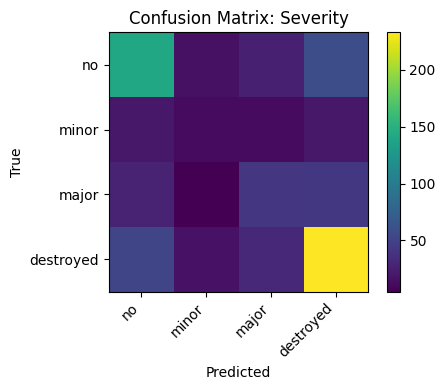

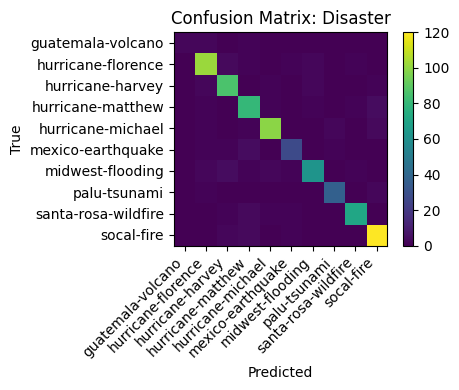

In [ ]:
import matplotlib.pyplot as plt

def plot_cm(cm, title, tick_labels=None):
    plt.figure(figsize=(5,4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    if tick_labels is not None:
        plt.xticks(range(len(tick_labels)), tick_labels, rotation=45, ha="right")
        plt.yticks(range(len(tick_labels)), tick_labels)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

plot_cm(cm_sev, "Confusion Matrix: Severity", tick_labels=["no", "minor", "major", "destroyed"])
plot_cm(cm_dis, "Confusion Matrix: Disaster", tick_labels=list(dis_enc.classes_))


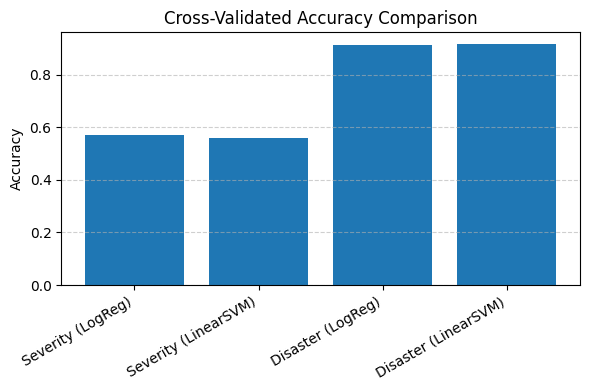

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Build plotting table
plot_df = summary.copy()

# Extract means
plot_df["acc_mean"] = plot_df["acc"].str.split(" ").str[0].astype(float)

plt.figure(figsize=(6,4))
plt.bar(plot_df["task"], plot_df["acc_mean"])
plt.ylabel("Accuracy")
plt.title("Cross-Validated Accuracy Comparison")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


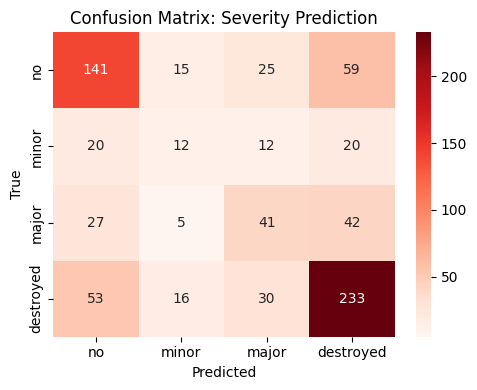

In [ ]:
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_sev,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["no", "minor", "major", "destroyed"],
    yticklabels=["no", "minor", "major", "destroyed"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix: Severity Prediction")
plt.tight_layout()
plt.show()


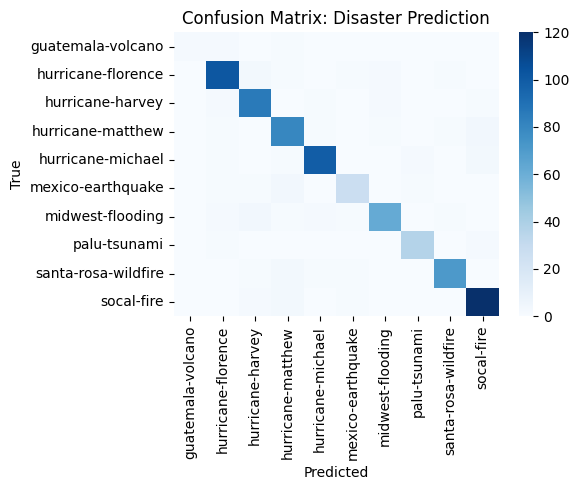

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_dis,
    annot=False,
    cmap="Blues",
    xticklabels=dis_enc.classes_,
    yticklabels=dis_enc.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix: Disaster Prediction")
plt.tight_layout()
plt.show()


## Model run start from here

In [24]:
# STEP 1: Create (image_path, json_path, label) records

import os, json, glob
from collections import Counter

SEVERITY_ORDER = {"no-damage": 0, "minor-damage": 1, "major-damage": 2, "destroyed": 3}
IDX2NAME = {v:k for k,v in SEVERITY_ORDER.items()}

def parse_xbd_tile_label(json_path: str) -> int | None:
    """
    Returns tile-level severity label (0..3) using max building severity.
    Returns None if no valid buildings exist.
    """
    with open(json_path, "r") as f:
        data = json.load(f)

    feats = data.get("features", {}).get("xy", [])
    best = None
    for feat in feats:
        props = feat.get("properties", {})
        sub = props.get("subtype")  # usually: no-damage/minor-damage/major-damage/destroyed
        if sub in SEVERITY_ORDER:
            s = SEVERITY_ORDER[sub]
            best = s if best is None else max(best, s)
    return best

# ---- CHANGE THESE PATHS ----
POST_IMG_DIR = "/content/xview2_part_aa/geotiffs/hold/images"   # e.g. .../images
LABEL_DIR    = "/content/xview2_part_aa/geotiffs/hold/labels"                # e.g. .../labels
# ----------------------------

# Try to find tif + json pairs by common basename
img_paths = sorted(glob.glob(os.path.join(POST_IMG_DIR, "**", "*.tif"), recursive=True))

records = []
for img_path in img_paths:
    base = os.path.splitext(os.path.basename(img_path))[0]
    # common xBD naming: "<base>_post_disaster.tif" and "<base>_post_disaster.json"
    # adjust if your names differ
    cand_json = os.path.join(LABEL_DIR, base + ".json")
    if not os.path.exists(cand_json):
        continue

    y = parse_xbd_tile_label(cand_json)
    if y is None:
        continue

    records.append((img_path, cand_json, y))

print("Total tiles:", len(records))
print("Class counts:", Counter([r[2] for r in records]))

Total tiles: 751
Class counts: Counter({3: 332, 0: 240, 2: 115, 1: 64})


In [25]:
# STEP 2: Stratified Train/Val Split

from sklearn.model_selection import train_test_split

X = [r[:2] for r in records]  # (img_path, json_path)
y = [r[2] for r in records]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", len(X_train), "Val:", len(X_val))

Train: 600 Val: 151


In [26]:
# STEP 3: Dataset + DataLoader

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import rasterio
import cv2

import torchvision.transforms as T

# ImageNet normalization (works well for pretrained ResNet/EfficientNet)
train_tf = T.Compose([
    T.ToPILImage(),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
])

val_tf = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
])

def read_geotiff_rgb(path: str) -> np.ndarray:
    """
    Returns HxWx3 uint8-ish RGB array.
    If values are not in 0..255, we normalize to 0..255.
    """
    with rasterio.open(path) as src:
        # read first 3 bands
        img = src.read([1,2,3])  # (3, H, W)
    img = np.transpose(img, (1,2,0)).astype(np.float32)

    # normalize to 0..255 for transforms
    mn, mx = np.nanmin(img), np.nanmax(img)
    if mx > mn:
        img = (img - mn) / (mx - mn)
    img = (img * 255.0).clip(0, 255).astype(np.uint8)
    return img

class XBDTileDataset(Dataset):
    def __init__(self, X, y, transform):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img_path, _json_path = self.X[idx]
        label = self.y[idx]
        img = read_geotiff_rgb(img_path)
        img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

train_ds = XBDTileDataset(X_train, y_train, train_tf)
val_ds   = XBDTileDataset(X_val, y_val, val_tf)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

### Model 1: resnet50

In [ ]:
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import torchvision.models as models
from collections import Counter

In [ ]:
# STEP 4: Train + Evaluate

import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import torchvision.models as models
from collections import Counter

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

NUM_CLASSES = 4

def make_model(name="resnet50", num_classes=4):
    if name == "resnet50":
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
        return m
    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
        return m
    else:
        raise ValueError("Unknown model name")

# Choose one:
MODEL_NAME = "resnet50"         # or "efficientnet_b0"
model = make_model(MODEL_NAME, NUM_CLASSES).to(device)

# ---- Optional: class-balanced weights ----
counts = Counter(y_train)
total = sum(counts.values())
class_weights = torch.tensor(
    [total / (counts.get(i, 1)) for i in range(NUM_CLASSES)],
    dtype=torch.float32
).to(device)

USE_CLASS_WEIGHTS = True
criterion = nn.CrossEntropyLoss(weight=class_weights if USE_CLASS_WEIGHTS else None)

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()
    losses = []
    all_preds, all_true = [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        with torch.set_grad_enabled(train):
            logits = model(imgs)
            loss = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        losses.append(loss.item())
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_true.extend(labels.detach().cpu().numpy().tolist())

    return float(np.mean(losses)), all_true, all_preds

EPOCHS = 10

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_y, tr_p = run_epoch(model, train_loader, train=True)
    va_loss, va_y, va_p = run_epoch(model, val_loader, train=False)
    scheduler.step()

    tr_acc = accuracy_score(tr_y, tr_p)
    va_acc = accuracy_score(va_y, va_p)
    va_f1  = f1_score(va_y, va_p, average="macro")

    print(f"Epoch {epoch:02d} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.3f} macroF1 {va_f1:.3f}")

print("\nConfusion Matrix (val):")
print(confusion_matrix(va_y, va_p))

Device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 193MB/s]


Epoch 01 | train loss 1.3312 acc 0.428 | val loss 1.2498 acc 0.530 macroF1 0.454
Epoch 02 | train loss 1.1386 acc 0.590 | val loss 1.1683 acc 0.543 macroF1 0.448
Epoch 03 | train loss 0.9848 acc 0.645 | val loss 1.1418 acc 0.603 macroF1 0.506
Epoch 04 | train loss 0.8229 acc 0.692 | val loss 1.1443 acc 0.570 macroF1 0.503
Epoch 05 | train loss 0.6611 acc 0.740 | val loss 1.2059 acc 0.563 macroF1 0.485
Epoch 06 | train loss 0.6224 acc 0.772 | val loss 1.1657 acc 0.570 macroF1 0.481
Epoch 07 | train loss 0.5306 acc 0.818 | val loss 1.2310 acc 0.563 macroF1 0.499
Epoch 08 | train loss 0.4676 acc 0.852 | val loss 1.2336 acc 0.596 macroF1 0.524
Epoch 09 | train loss 0.4420 acc 0.847 | val loss 1.2329 acc 0.623 macroF1 0.542
Epoch 10 | train loss 0.4171 acc 0.872 | val loss 1.2150 acc 0.623 macroF1 0.543

Confusion Matrix (val):
[[32  5  1 10]
 [ 5  3  2  3]
 [ 2  2 15  4]
 [ 8  7  8 44]]


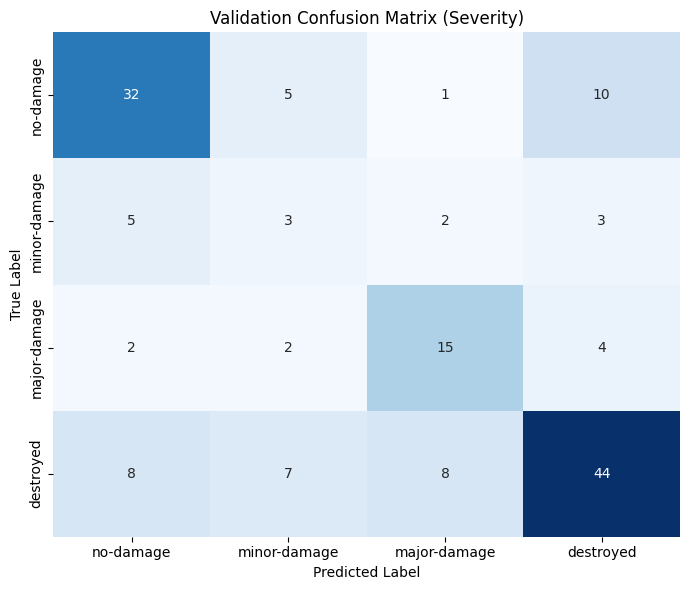

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(cm, labels, title="Confusion Matrix"):
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# The confusion matrix was already computed in the previous cell
# as cm = confusion_matrix(va_y, va_p)
# The labels correspond to the SEVERITY_ORDER defined earlier.
severity_labels = [IDX2NAME[i] for i in range(NUM_CLASSES)]

plot_confusion_matrix(confusion_matrix(va_y, va_p), severity_labels,
                      title="Validation Confusion Matrix (Severity)")

### Model 2: efficientnet_b0

In [ ]:
# STEP 4: Train + Evaluate (with result saving)

import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import torchvision.models as models
from collections import Counter
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

NUM_CLASSES = 4

# Global results dictionary (keeps all experiments)
if "experiment_results" not in globals():
    experiment_results = {}

def make_model(name="resnet50", num_classes=4):
    if name == "resnet50":
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
        return m
    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
        return m
    else:
        raise ValueError("Unknown model name")

# ---- SET THESE BEFORE RUNNING ----
MODEL_NAME = "efficientnet_b0"
USE_CLASS_WEIGHTS = True
EXPERIMENT_NAME = f"{MODEL_NAME}_weighted_{USE_CLASS_WEIGHTS}"
# ----------------------------------

model = make_model(MODEL_NAME, NUM_CLASSES).to(device)

# ---- Class weights ----
counts = Counter(y_train)
total = sum(counts.values())
class_weights = torch.tensor(
    [total / (counts.get(i, 1)) for i in range(NUM_CLASSES)],
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights if USE_CLASS_WEIGHTS else None)

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()
    losses = []
    all_preds, all_true = [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        with torch.set_grad_enabled(train):
            logits = model(imgs)
            loss = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        losses.append(loss.item())
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_true.extend(labels.detach().cpu().numpy())

    return float(np.mean(losses)), np.array(all_true), np.array(all_preds)

EPOCHS = 10

history = {"val_acc": [], "val_f1": []}

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_y, tr_p = run_epoch(model, train_loader, train=True)
    va_loss, va_y, va_p = run_epoch(model, val_loader, train=False)
    scheduler.step()

    tr_acc = accuracy_score(tr_y, tr_p)
    va_acc = accuracy_score(va_y, va_p)
    va_f1  = f1_score(va_y, va_p, average="macro")

    history["val_acc"].append(va_acc)
    history["val_f1"].append(va_f1)

    print(f"Epoch {epoch:02d} | "
          f"train acc {tr_acc:.3f} | "
          f"val acc {va_acc:.3f} | "
          f"val macroF1 {va_f1:.3f}")

cm = confusion_matrix(va_y, va_p)

# Save experiment results
experiment_results[EXPERIMENT_NAME] = {
    "final_val_acc": history["val_acc"][-1],
    "final_val_f1": history["val_f1"][-1],
    "confusion_matrix": cm,
    "history": history
}

print("\nSaved experiment:", EXPERIMENT_NAME)
print("Final Val Accuracy:", history["val_acc"][-1])
print("Final Val MacroF1:", history["val_f1"][-1])
print("Confusion Matrix:\n", cm)

Device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 183MB/s]


Epoch 01 | train acc 0.378 | val acc 0.497 | val macroF1 0.446
Epoch 02 | train acc 0.520 | val acc 0.576 | val macroF1 0.522
Epoch 03 | train acc 0.580 | val acc 0.603 | val macroF1 0.532
Epoch 04 | train acc 0.645 | val acc 0.583 | val macroF1 0.508
Epoch 05 | train acc 0.642 | val acc 0.576 | val macroF1 0.505
Epoch 06 | train acc 0.705 | val acc 0.623 | val macroF1 0.532
Epoch 07 | train acc 0.673 | val acc 0.556 | val macroF1 0.475
Epoch 08 | train acc 0.708 | val acc 0.563 | val macroF1 0.462
Epoch 09 | train acc 0.733 | val acc 0.576 | val macroF1 0.491
Epoch 10 | train acc 0.728 | val acc 0.596 | val macroF1 0.492

Saved experiment: efficientnet_b0_weighted_True
Final Val Accuracy: 0.5960264900662252
Final Val MacroF1: 0.4921058201058201
Confusion Matrix:
 [[29  6  4  9]
 [ 3  1  4  5]
 [ 2  3 17  1]
 [ 5  4 15 43]]


In [ ]:
import numpy as np

cm = experiment_results["efficientnet_b0_weighted_True"]["confusion_matrix"]

class_names = ["no-damage", "minor", "major", "destroyed"]

for i, name in enumerate(class_names):
    recall = cm[i, i] / cm[i].sum()
    print(f"{name} accuracy: {recall:.3f}")

no-damage accuracy: 0.604
minor accuracy: 0.077
major accuracy: 0.739
destroyed accuracy: 0.642


### Focus Only on minor-damage vs others

In [ ]:
# STEP A: Convert dataset to Minor vs Rest

MINOR_CLASS_INDEX = 1  # from your mapping

def convert_to_minor_binary(y_list):
    return [1 if y == MINOR_CLASS_INDEX else 0 for y in y_list]

y_train_minor = convert_to_minor_binary(y_train)
y_val_minor   = convert_to_minor_binary(y_val)

print("Train minor count:", sum(y_train_minor))
print("Val minor count:", sum(y_val_minor))

Train minor count: 51
Val minor count: 13


In [ ]:
# STEP B: Create new DataLoaders for binary classification

train_ds_minor = XBDTileDataset(X_train, y_train_minor, train_tf)
val_ds_minor   = XBDTileDataset(X_val, y_val_minor, val_tf)

train_loader_minor = DataLoader(train_ds_minor, batch_size=16, shuffle=True, num_workers=2)
val_loader_minor   = DataLoader(val_ds_minor, batch_size=16, shuffle=False, num_workers=2)

In [ ]:
# STEP C: Train Binary Classifier (Minor vs Rest)

import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

NUM_CLASSES = 2

MODEL_NAME = "efficientnet_b0"  

model = make_model(MODEL_NAME, NUM_CLASSES).to(device)

# Class balancing for binary
from collections import Counter
counts = Counter(y_train_minor)
total = sum(counts.values())

class_weights = torch.tensor(
    [total/counts.get(0,1), total/counts.get(1,1)],
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

EPOCHS = 10

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_y, tr_p = run_epoch(model, train_loader_minor, train=True)
    va_loss, va_y, va_p = run_epoch(model, val_loader_minor, train=False)
    scheduler.step()

    va_acc = accuracy_score(va_y, va_p)
    va_f1  = f1_score(va_y, va_p, average="macro")

    print(f"Epoch {epoch:02d} | Val Acc {va_acc:.3f} | Val MacroF1 {va_f1:.3f}")

print("\nConfusion Matrix (Minor vs Rest):")
cm_minor = confusion_matrix(va_y, va_p)
print(cm_minor)

print("\nClassification Report:")
print(classification_report(va_y, va_p, target_names=["Not Minor", "Minor"]))

Epoch 01 | Val Acc 0.689 | Val MacroF1 0.478
Epoch 02 | Val Acc 0.669 | Val MacroF1 0.480
Epoch 03 | Val Acc 0.689 | Val MacroF1 0.517
Epoch 04 | Val Acc 0.709 | Val MacroF1 0.504
Epoch 05 | Val Acc 0.801 | Val MacroF1 0.568
Epoch 06 | Val Acc 0.781 | Val MacroF1 0.553
Epoch 07 | Val Acc 0.821 | Val MacroF1 0.584
Epoch 08 | Val Acc 0.828 | Val MacroF1 0.569
Epoch 09 | Val Acc 0.808 | Val MacroF1 0.553
Epoch 10 | Val Acc 0.808 | Val MacroF1 0.573

Confusion Matrix (Minor vs Rest):
[[117  21]
 [  8   5]]

Classification Report:
              precision    recall  f1-score   support

   Not Minor       0.94      0.85      0.89       138
       Minor       0.19      0.38      0.26        13

    accuracy                           0.81       151
   macro avg       0.56      0.62      0.57       151
weighted avg       0.87      0.81      0.84       151



### Build Building-Crop Training (Minor Only First)

In [ ]:
import re
import numpy as np

def wkt_to_bbox(wkt_string):
    """
    Converts WKT polygon string to pixel bounding box.
    Returns (xmin, ymin, xmax, ymax) or None if WKT is malformed.
    """
    # Extract numbers
    coords = re.findall(r"[-+]?\d*\.\d+|\d+", wkt_string)
    coords = list(map(float, coords))

    # Check for malformed WKT (empty or odd number of coordinates)
    if not coords or len(coords) % 2 != 0:
        return None

    # Group into (x,y)
    points = [(coords[i], coords[i+1]) for i in range(0, len(coords), 2)]

    xs = [p[0] for p in points]
    ys = [p[1] for p in points]

    # Check if points are empty after parsing
    if not xs or not ys:
        return None

    xmin, xmax = min(xs), max(xs)
    ymin, ymax = min(ys), max(ys)

    return int(xmin), int(ymin), int(xmax), int(ymax)

In [ ]:
# STEP 2: Extract building-level dataset (Minor vs Rest)

building_records = []

for img_path, json_path, _ in records:

    with open(json_path, "r") as f:
        data = json.load(f)

    feats = data["features"]["xy"]

    for feat in feats:
        subtype = feat["properties"]["subtype"]
        wkt = feat["wkt"]

        if subtype not in SEVERITY_ORDER:
            continue

        bbox = wkt_to_bbox(wkt)
        if bbox is None: # Skip if WKT is malformed and returned None
            continue

        xmin, ymin, xmax, ymax = bbox

        # Binary label: minor vs rest
        label = 1 if subtype == "minor-damage" else 0

        building_records.append((img_path, xmin, ymin, xmax, ymax, label))

print("Total building samples:", len(building_records))

Total building samples: 52537


In [ ]:
class XBDBuildingDataset(torch.utils.data.Dataset):
    def __init__(self, records, transform):
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        img_path, xmin, ymin, xmax, ymax, label = self.records[idx]

        img = read_geotiff_rgb(img_path)

        # Add padding
        pad = 10
        xmin = max(0, xmin - pad)
        ymin = max(0, ymin - pad)
        xmax = min(img.shape[1], xmax + pad)
        ymax = min(img.shape[0], ymax + pad)

        crop = img[ymin:ymax, xmin:xmax]

        crop = self.transform(crop)

        return crop, torch.tensor(label, dtype=torch.long)

In [ ]:
from sklearn.model_selection import train_test_split

train_buildings, val_buildings = train_test_split(
    building_records,
    test_size=0.2,
    random_state=42,
    stratify=[r[-1] for r in building_records]
)

train_ds_b = XBDBuildingDataset(train_buildings, train_tf)
val_ds_b   = XBDBuildingDataset(val_buildings, val_tf)

train_loader_b = DataLoader(train_ds_b, batch_size=32, shuffle=True)
val_loader_b   = DataLoader(val_ds_b, batch_size=32, shuffle=False)

print("Train buildings:", len(train_ds_b))
print("Val buildings:", len(val_ds_b))

Train buildings: 42029
Val buildings: 10508


In [ ]:
# ===============================
# STEP 5: FAST Building-Level Training (Minor vs Rest)
# ===============================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from collections import Counter
import numpy as np
import rasterio

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ===============================
# 1️⃣ CACHE IMAGE LOADING
# ===============================

image_cache = {}

def read_geotiff_rgb_cached(path):
    if path not in image_cache:
        with rasterio.open(path) as src:
            img = src.read([1,2,3])
        img = np.transpose(img, (1,2,0)).astype(np.float32)
        mn, mx = np.nanmin(img), np.nanmax(img)
        if mx > mn:
            img = (img - mn) / (mx - mn)
        img = (img * 255.0).clip(0,255).astype(np.uint8)
        image_cache[path] = img
    return image_cache[path]

# ===============================
# 2️⃣ UPDATE DATASET TO USE CACHE
# ===============================

class XBDBuildingDataset(torch.utils.data.Dataset):
    def __init__(self, records, transform):
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        img_path, xmin, ymin, xmax, ymax, label = self.records[idx]

        img = read_geotiff_rgb_cached(img_path)

        pad = 10
        xmin = max(0, xmin - pad)
        ymin = max(0, ymin - pad)
        xmax = min(img.shape[1], xmax + pad)
        ymax = min(img.shape[0], ymax + pad)

        crop = img[ymin:ymax, xmin:xmax]
        crop = self.transform(crop)

        return crop, torch.tensor(label, dtype=torch.long)

# ===============================
# 3️⃣ DATA LOADERS
# ===============================

train_ds_b = XBDBuildingDataset(train_buildings, train_tf)
val_ds_b   = XBDBuildingDataset(val_buildings, val_tf)

train_loader_b = DataLoader(train_ds_b, batch_size=16, shuffle=True, num_workers=0)
val_loader_b   = DataLoader(val_ds_b, batch_size=16, shuffle=False, num_workers=0)

print("Train buildings:", len(train_ds_b))
print("Val buildings:", len(val_ds_b))

# ===============================
# 4️⃣ MODEL
# ===============================

NUM_CLASSES = 2
MODEL_NAME = "efficientnet_b0"

if MODEL_NAME == "resnet50":
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

elif MODEL_NAME == "efficientnet_b0":
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)

# Freeze backbone (fast + stable)
for param in model.parameters():
    param.requires_grad = False

if MODEL_NAME == "resnet50":
    for param in model.fc.parameters():
        param.requires_grad = True
elif MODEL_NAME == "efficientnet_b0":
    for param in model.classifier.parameters():
        param.requires_grad = True

model = model.to(device)

# ===============================
# 5️⃣ CLASS WEIGHTS
# ===============================

train_labels = [r[-1] for r in train_buildings]
counts = Counter(train_labels)
total = sum(counts.values())

class_weights = torch.tensor(
    [total/counts.get(0,1), total/counts.get(1,1)],
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-4)

# ===============================
# 6️⃣ TRAIN LOOP
# ===============================

def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()
    all_preds, all_true = [], []

    for step, (imgs, labels) in enumerate(loader):
        imgs, labels = imgs.to(device), labels.to(device)

        with torch.set_grad_enabled(train):
            logits = model(imgs)
            loss = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        if step % 500 == 0:
            print(f"Step {step}/{len(loader)}")

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_true.extend(labels.detach().cpu().numpy())

    return np.array(all_true), np.array(all_preds)

EPOCHS = 3   # start small

for epoch in range(1, EPOCHS+1):
    print(f"\nEpoch {epoch}")
    tr_y, tr_p = run_epoch(model, train_loader_b, train=True)
    va_y, va_p = run_epoch(model, val_loader_b, train=False)

    va_acc = accuracy_score(va_y, va_p)
    va_f1  = f1_score(va_y, va_p, average="macro")

    print(f"Val Accuracy: {va_acc:.3f}")
    print(f"Val MacroF1: {va_f1:.3f}")

# ===============================
# 7️⃣ FINAL RESULTS
# ===============================

cm = confusion_matrix(va_y, va_p)

print("\nConfusion Matrix (Building-Level Minor vs Rest):")
print(cm)

print("\nClassification Report:")
print(classification_report(va_y, va_p, target_names=["Not Minor", "Minor"]))

Device: cuda
Train buildings: 42029
Val buildings: 10508

Epoch 1
Step 0/2627
Step 500/2627
Step 1000/2627
Step 1500/2627
Step 2000/2627
Step 2500/2627
Step 0/657
Step 500/657
Val Accuracy: 0.783
Val MacroF1: 0.647

Epoch 2
Step 0/2627
Step 500/2627
Step 1000/2627
Step 1500/2627
Step 2000/2627
Step 2500/2627
Step 0/657
Step 500/657
Val Accuracy: 0.801
Val MacroF1: 0.658

Epoch 3
Step 0/2627
Step 500/2627
Step 1000/2627
Step 1500/2627
Step 2000/2627
Step 2500/2627
Step 0/657
Step 500/657
Val Accuracy: 0.805
Val MacroF1: 0.666

Confusion Matrix (Building-Level Minor vs Rest):
[[7611 1637]
 [ 417  843]]

Classification Report:
              precision    recall  f1-score   support

   Not Minor       0.95      0.82      0.88      9248
       Minor       0.34      0.67      0.45      1260

    accuracy                           0.80     10508
   macro avg       0.64      0.75      0.67     10508
weighted avg       0.88      0.80      0.83     10508



 ### no-damage vs minor-damage only Building-Crop Training

In [ ]:
# ============================================================
# 4-CLASS Building-Crop Training (Efficient for T4) + Save Results
# ============================================================

import torch, numpy as np, rasterio
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import DataLoader
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import time

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ----------------------------
# Experiment results container
# ----------------------------
if "experiment_results" not in globals():
    experiment_results = {}

# ----------------------------
# Label mapping
# Ensure your SEVERITY_ORDER is: {"no-damage":0,"minor-damage":1,"major-damage":2,"destroyed":3}
# ----------------------------
IDX2NAME = {v: k for k, v in SEVERITY_ORDER.items()}
CLASS_NAMES = [IDX2NAME[i] for i in range(4)]
NUM_CLASSES = 4

# ----------------------------
# Fast GeoTIFF caching
# ----------------------------
image_cache = {}

def read_geotiff_rgb_cached(path: str) -> np.ndarray:
    if path not in image_cache:
        with rasterio.open(path) as src:
            img = src.read([1,2,3])  # (3, H, W)
        img = np.transpose(img, (1,2,0)).astype(np.float32)

        mn, mx = np.nanmin(img), np.nanmax(img)
        if mx > mn:
            img = (img - mn) / (mx - mn)
        img = (img * 255.0).clip(0,255).astype(np.uint8)

        image_cache[path] = img
    return image_cache[path]

# ----------------------------
# Dataset (building crops)
# record format expected: (img_path, xmin, ymin, xmax, ymax, label_int_0to3)
# ----------------------------
class XBDBuildingDataset4C(torch.utils.data.Dataset):
    def __init__(self, records, transform, pad=10):
        self.records = records
        self.transform = transform
        self.pad = pad

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        img_path, xmin, ymin, xmax, ymax, y = self.records[idx]
        img = read_geotiff_rgb_cached(img_path)

        # pad + clip
        xmin = max(0, int(xmin) - self.pad)
        ymin = max(0, int(ymin) - self.pad)
        xmax = min(img.shape[1], int(xmax) + self.pad)
        ymax = min(img.shape[0], int(ymax) + self.pad)

        crop = img[ymin:ymax, xmin:xmax]
        crop = self.transform(crop)

        return crop, torch.tensor(int(y), dtype=torch.long)

# ----------------------------
# DataLoaders (num_workers=0 is often safest on Colab)
# ----------------------------
BATCH_SIZE = 16
train_ds_b4 = XBDBuildingDataset4C(train_buildings, train_tf, pad=10)
val_ds_b4   = XBDBuildingDataset4C(val_buildings, val_tf, pad=10)

train_loader_b4 = DataLoader(train_ds_b4, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader_b4   = DataLoader(val_ds_b4, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print("Train buildings:", len(train_ds_b4))
print("Val buildings:", len(val_ds_b4))

# ----------------------------
# Model
# ----------------------------
MODEL_NAME = "efficientnet_b0"  # "resnet50" also supported
FREEZE_BACKBONE = True         # start True for speed/stability. Later you can set False or partial unfreeze.

def make_model_4c(name: str):
    if name == "resnet50":
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
        return m
    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, NUM_CLASSES)
        return m
    else:
        raise ValueError("Unknown model")

model = make_model_4c(MODEL_NAME)

# Freeze backbone (fast + avoids overfit early)
if FREEZE_BACKBONE:
    for p in model.parameters():
        p.requires_grad = False
    if MODEL_NAME == "resnet50":
        for p in model.fc.parameters():
            p.requires_grad = True
    else:
        for p in model.classifier.parameters():
            p.requires_grad = True

model = model.to(device)

# ----------------------------
# Weighted Cross Entropy (class imbalance)
# ----------------------------
train_labels_4c = [r[-1] for r in train_buildings]
counts = Counter(train_labels_4c)
total = sum(counts.values())
class_weights = torch.tensor([total / counts.get(i, 1) for i in range(NUM_CLASSES)], dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

# Only train params with requires_grad=True
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-4, weight_decay=1e-4)

# ----------------------------
# Train / Eval loop with progress prints + early stopping
# ----------------------------
def run_epoch(model, loader, train=True, log_every=500):
    model.train() if train else model.eval()
    all_true, all_pred = [], []
    running_loss = 0.0

    for step, (x, y) in enumerate(loader):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.set_grad_enabled(train):
            logits = model(x)
            loss = criterion(logits, y)

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        running_loss += loss.item()
        pred = torch.argmax(logits, dim=1)

        all_true.extend(y.detach().cpu().numpy())
        all_pred.extend(pred.detach().cpu().numpy())

        if step % log_every == 0:
            print(f"  Step {step}/{len(loader)}")

    avg_loss = running_loss / max(1, len(loader))
    return avg_loss, np.array(all_true), np.array(all_pred)

# Early stopping config
EPOCHS = 5
PATIENCE = 2   # stop if no improvement for 2 epochs
best_val_f1 = -1
best_state = None
epochs_no_improve = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_macro_f1": []
}

EXP_NAME = f"bldg4c_{MODEL_NAME}_freeze{FREEZE_BACKBONE}_wce_bs{BATCH_SIZE}"

print("\nRunning experiment:", EXP_NAME)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    print(f"\nEpoch {epoch}")

    tr_loss, tr_y, tr_p = run_epoch(model, train_loader_b4, train=True, log_every=500)
    va_loss, va_y, va_p = run_epoch(model, val_loader_b4, train=False, log_every=500)

    va_acc = accuracy_score(va_y, va_p)
    va_f1  = f1_score(va_y, va_p, average="macro")

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)
    history["val_macro_f1"].append(va_f1)

    print(f"  Train loss: {tr_loss:.4f} | Val loss: {va_loss:.4f}")
    print(f"  Val Acc: {va_acc:.3f} | Val MacroF1: {va_f1:.3f} | epoch time: {time.time()-t0:.1f}s")

    # Early stopping on macro-F1
    if va_f1 > best_val_f1 + 1e-4:
        best_val_f1 = va_f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        best_epoch = epoch
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping: no improvement for {PATIENCE} epochs (best epoch={best_epoch}, best macroF1={best_val_f1:.3f})")
            break

# Restore best weights
if best_state is not None:
    model.load_state_dict(best_state)
    print(f"\nRestored best model from epoch {best_epoch} (macroF1={best_val_f1:.3f})")

# Final eval (best model)
_, va_y, va_p = run_epoch(model, val_loader_b4, train=False, log_every=500)
cm = confusion_matrix(va_y, va_p)
report = classification_report(va_y, va_p, target_names=CLASS_NAMES, digits=4, output_dict=True)

final_val_acc = accuracy_score(va_y, va_p)
final_val_f1  = f1_score(va_y, va_p, average="macro")

# Per-class recall (this is what you care about for minor/major)
per_class_recall = {CLASS_NAMES[i]: cm[i, i] / max(1, cm[i, :].sum()) for i in range(NUM_CLASSES)}
per_class_precision = {}
for j in range(NUM_CLASSES):
    denom = cm[:, j].sum()
    per_class_precision[CLASS_NAMES[j]] = (cm[j, j] / denom) if denom > 0 else 0.0

# Save results
experiment_results[EXP_NAME] = {
    "final_val_acc": float(final_val_acc),
    "final_val_macro_f1": float(final_val_f1),
    "confusion_matrix": cm,
    "class_names": CLASS_NAMES,
    "per_class_recall": per_class_recall,
    "per_class_precision": per_class_precision,
    "history": history,
    "best_epoch": int(best_epoch) if best_state is not None else None,
    "freeze_backbone": bool(FREEZE_BACKBONE),
    "model_name": MODEL_NAME,
    "batch_size": int(BATCH_SIZE),
}

print("\n=== Final (Best) Validation Results ===")
print("Experiment:", EXP_NAME)
print("Val Accuracy:", final_val_acc)
print("Val MacroF1:", final_val_f1)
print("Per-class recall:", per_class_recall)
print("\nConfusion Matrix:\n", cm)

Device: cuda
Train buildings: 42029
Val buildings: 10508

Running experiment: bldg4c_efficientnet_b0_freezeTrue_wce_bs16

Epoch 1
  Step 0/2627
  Step 500/2627
  Step 1000/2627
  Step 1500/2627
  Step 2000/2627
  Step 2500/2627
  Step 0/657
  Step 500/657
  Train loss: 0.5961 | Val loss: 0.5452
  Val Acc: 0.769 | Val MacroF1: 0.315 | epoch time: 213.5s

Epoch 2
  Step 0/2627
  Step 500/2627
  Step 1000/2627
  Step 1500/2627
  Step 2000/2627
  Step 2500/2627
  Step 0/657
  Step 500/657
  Train loss: 0.5607 | Val loss: 0.5306
  Val Acc: 0.793 | Val MacroF1: 0.326 | epoch time: 178.1s

Epoch 3
  Step 0/2627
  Step 500/2627
  Step 1000/2627
  Step 1500/2627
  Step 2000/2627
  Step 2500/2627
  Step 0/657
  Step 500/657
  Train loss: 0.5533 | Val loss: 0.5152
  Val Acc: 0.796 | Val MacroF1: 0.327 | epoch time: 180.7s

Epoch 4
  Step 0/2627
  Step 500/2627
  Step 1000/2627
  Step 1500/2627
  Step 2000/2627
  Step 2500/2627
  Step 0/657
  Step 500/657
  Train loss: 0.5469 | Val loss: 0.5248
  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


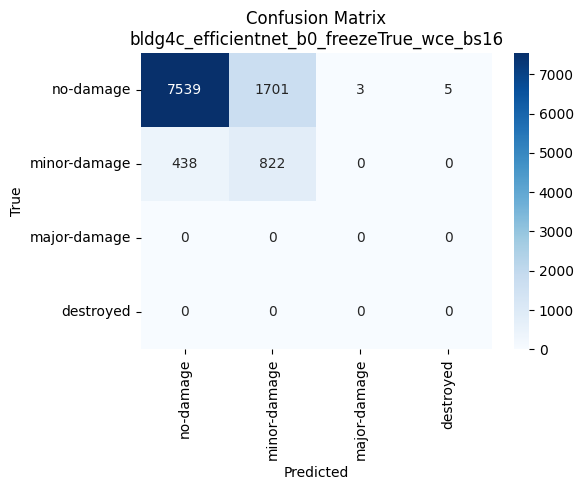

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Choose experiment
EXP_NAME = list(experiment_results.keys())[-1]  # last run

cm = experiment_results[EXP_NAME]["confusion_matrix"]
class_names = experiment_results[EXP_NAME]["class_names"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix\n{EXP_NAME}")
plt.tight_layout()
plt.show()

/tmp/ipykernel_3895/2267081120.py:1: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)


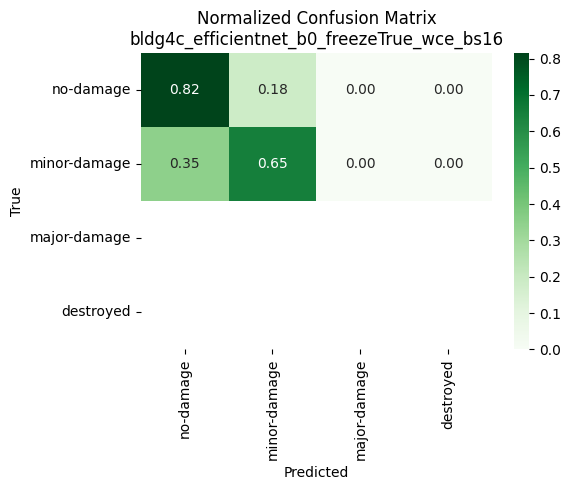

In [ ]:
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Normalized Confusion Matrix\n{EXP_NAME}")
plt.tight_layout()
plt.show()

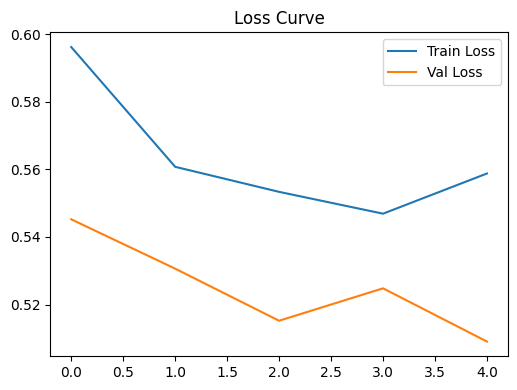

In [ ]:
history = experiment_results[EXP_NAME]["history"]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter

print("Train class distribution:")
print(Counter([r[-1] for r in train_buildings]))

print("\nVal class distribution:")
print(Counter([r[-1] for r in val_buildings]))

Train class distribution:
Counter({0: 36987, 1: 5042})

Val class distribution:
Counter({0: 9248, 1: 1260})


# 4 class

In [ ]:
# ===============================
# STEP 1: Rebuild FULL 4-Class Building Dataset
# ===============================

import json
from collections import Counter

# 4-class mapping
SEVERITY_ORDER = {
    "no-damage": 0,
    "minor-damage": 1,
    "major-damage": 2,
    "destroyed": 3
}

building_records_4c = []

for img_path, json_path, _ in records:   # records = tile-level list from earlier
    with open(json_path, "r") as f:
        data = json.load(f)

    feats = data["features"]["xy"]

    for feat in feats:
        subtype = feat["properties"]["subtype"]
        if subtype not in SEVERITY_ORDER:
            continue

        label = SEVERITY_ORDER[subtype]
        wkt = feat["wkt"]

        bbox = wkt_to_bbox(wkt)
        if bbox is None: # Skip if WKT is malformed
            continue
        xmin, ymin, xmax, ymax = bbox

        building_records_4c.append(
            (img_path, xmin, ymin, xmax, ymax, label)
        )

print("Total building samples:", len(building_records_4c))

# Check distribution
labels_all = [r[-1] for r in building_records_4c]
print("Full class distribution:", Counter(labels_all))


Total building samples: 52537
Full class distribution: Counter({0: 37505, 1: 6302, 2: 4531, 3: 4199})


In [ ]:
# ===============================
# STEP 2: Stratified Split (4-Class)
# ===============================

from sklearn.model_selection import train_test_split

train_buildings_4c, val_buildings_4c = train_test_split(
    building_records_4c,
    test_size=0.2,
    random_state=42,
    stratify=[r[-1] for r in building_records_4c]
)

print("Train size:", len(train_buildings_4c))
print("Val size:", len(val_buildings_4c))

print("\nTrain distribution:", Counter([r[-1] for r in train_buildings_4c]))
print("Val distribution:", Counter([r[-1] for r in val_buildings_4c]))

Train size: 42029
Val size: 10508

Train distribution: Counter({0: 30004, 1: 5041, 2: 3625, 3: 3359})
Val distribution: Counter({0: 7501, 1: 1261, 2: 906, 3: 840})


In [ ]:
# ===============================
# STEP 3: Dataset with Correct 4-Class Records
# ===============================

train_ds_b4 = XBDBuildingDataset4C(train_buildings_4c, train_tf)
val_ds_b4   = XBDBuildingDataset4C(val_buildings_4c, val_tf)

train_loader_b4 = DataLoader(train_ds_b4, batch_size=16, shuffle=True, num_workers=0)
val_loader_b4   = DataLoader(val_ds_b4, batch_size=16, shuffle=False, num_workers=0)

print("Train buildings:", len(train_ds_b4))
print("Val buildings:", len(val_ds_b4))

Train buildings: 42029
Val buildings: 10508


In [ ]:
# ===============================
# STEP 4: Compute Class Weights (4-Class)
# ===============================

train_labels_4c = [r[-1] for r in train_buildings_4c]
counts = Counter(train_labels_4c)
total = sum(counts.values())

class_weights = torch.tensor(
    [total / counts.get(i,1) for i in range(4)],
    dtype=torch.float32
).to(device)

print("Class weights:", class_weights)

Class weights: tensor([ 1.4008,  8.3374, 11.5942, 12.5124], device='cuda:0')


In [ ]:
# ============================================================
# STEP 5: Train 4-Class Building-Crop Model (T4 Optimized)
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import numpy as np
import time

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# -----------------------------------
# Experiment container
# -----------------------------------
if "experiment_results" not in globals():
    experiment_results = {}

NUM_CLASSES = 4
CLASS_NAMES = ["no-damage", "minor-damage", "major-damage", "destroyed"]

MODEL_NAME = "efficientnet_b0"
FREEZE_BACKBONE = True
BATCH_SIZE = 16
EPOCHS = 5
PATIENCE = 2

EXP_NAME = f"bldg4c_{MODEL_NAME}_freeze{FREEZE_BACKBONE}_bs{BATCH_SIZE}"

print("\nRunning experiment:", EXP_NAME)

# -----------------------------------
# Model
# -----------------------------------
if MODEL_NAME == "resnet50":
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

elif MODEL_NAME == "efficientnet_b0":
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)

# Freeze backbone
if FREEZE_BACKBONE:
    for p in model.parameters():
        p.requires_grad = False
    if MODEL_NAME == "resnet50":
        for p in model.fc.parameters():
            p.requires_grad = True
    else:
        for p in model.classifier.parameters():
            p.requires_grad = True

model = model.to(device)

# -----------------------------------
# Loss & Optimizer
# -----------------------------------
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-4)

# -----------------------------------
# Train / Eval Loop
# -----------------------------------
def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()

    all_preds, all_true = [], []
    total_loss = 0.0

    for step, (imgs, labels) in enumerate(loader):
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.set_grad_enabled(train):
            logits = model(imgs)
            loss = criterion(logits, labels)

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_true.extend(labels.detach().cpu().numpy())

        if step % 500 == 0:
            print(f"  Step {step}/{len(loader)}")

    avg_loss = total_loss / len(loader)
    return avg_loss, np.array(all_true), np.array(all_preds)

# -----------------------------------
# Training with Early Stopping
# -----------------------------------
best_f1 = -1
best_state = None
epochs_no_improve = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_macro_f1": []
}

for epoch in range(1, EPOCHS+1):
    print(f"\nEpoch {epoch}")
    t0 = time.time()

    tr_loss, tr_y, tr_p = run_epoch(model, train_loader_b4, train=True)
    va_loss, va_y, va_p = run_epoch(model, val_loader_b4, train=False)

    val_acc = accuracy_score(va_y, va_p)
    val_f1 = f1_score(va_y, va_p, average="macro")

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(val_acc)
    history["val_macro_f1"].append(val_f1)

    print(f"  Train loss: {tr_loss:.4f} | Val loss: {va_loss:.4f}")
    print(f"  Val Acc: {val_acc:.3f} | Val MacroF1: {val_f1:.3f}")
    print(f"  Epoch time: {time.time()-t0:.1f}s")

    if val_f1 > best_f1 + 1e-4:
        best_f1 = val_f1
        best_state = model.state_dict()
        best_epoch = epoch
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping triggered (best epoch = {best_epoch})")
            break

# Restore best
model.load_state_dict(best_state)

# -----------------------------------
# Final Evaluation
# -----------------------------------
_, va_y, va_p = run_epoch(model, val_loader_b4, train=False)

cm = confusion_matrix(va_y, va_p)
final_acc = accuracy_score(va_y, va_p)
final_f1 = f1_score(va_y, va_p, average="macro")

report = classification_report(
    va_y, va_p,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

per_class_recall = {k: report[k]["recall"] for k in CLASS_NAMES}
per_class_precision = {k: report[k]["precision"] for k in CLASS_NAMES}

# Save results
experiment_results[EXP_NAME] = {
    "val_acc": final_acc,
    "val_macro_f1": final_f1,
    "confusion_matrix": cm,
    "per_class_recall": per_class_recall,
    "per_class_precision": per_class_precision,
    "history": history,
    "best_epoch": best_epoch
}

print("\n=== FINAL RESULTS ===")
print("Val Accuracy:", final_acc)
print("Val MacroF1:", final_f1)
print("Per-Class Recall:", per_class_recall)
print("\nConfusion Matrix:\n", cm)

Device: cuda

Running experiment: bldg4c_efficientnet_b0_freezeTrue_bs16

Epoch 1
  Step 0/2627
  Step 500/2627
  Step 1000/2627
  Step 1500/2627
  Step 2000/2627
  Step 2500/2627
  Step 0/657
  Step 500/657
  Train loss: 1.1009 | Val loss: 1.2911
  Val Acc: 0.667 | Val MacroF1: 0.546
  Epoch time: 180.0s

Epoch 2
  Step 0/2627
  Step 500/2627
  Step 1000/2627
  Step 1500/2627
  Step 2000/2627
  Step 2500/2627
  Step 0/657
  Step 500/657
  Train loss: 1.0296 | Val loss: 1.0215
  Val Acc: 0.681 | Val MacroF1: 0.563
  Epoch time: 179.6s

Epoch 3
  Step 0/2627
  Step 500/2627
  Step 1000/2627
  Step 1500/2627
  Step 2000/2627
  Step 2500/2627
  Step 0/657
  Step 500/657
  Train loss: 1.0158 | Val loss: 0.9806
  Val Acc: 0.671 | Val MacroF1: 0.550
  Epoch time: 180.9s

Epoch 4
  Step 0/2627
  Step 500/2627
  Step 1000/2627
  Step 1500/2627
  Step 2000/2627
  Step 2500/2627
  Step 0/657
  Step 500/657
  Train loss: 1.0091 | Val loss: 1.0217
  Val Acc: 0.681 | Val MacroF1: 0.552
  Epoch time

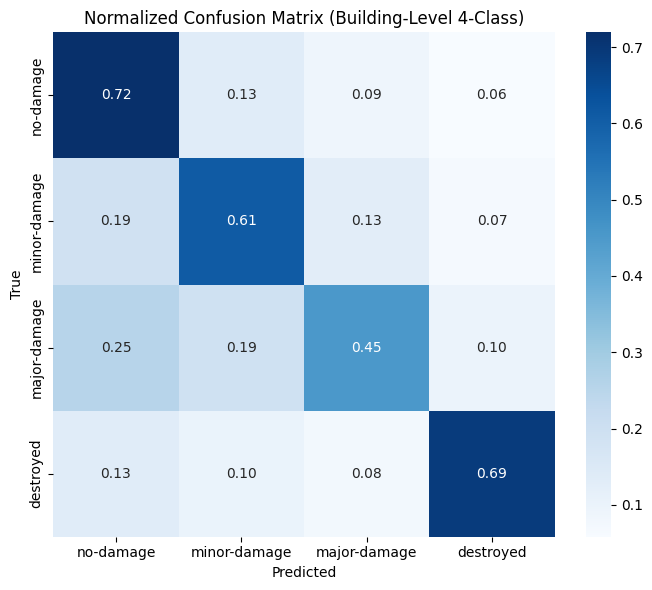

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = experiment_results["bldg4c_efficientnet_b0_freezeTrue_bs16"]["confusion_matrix"]
class_names = ["no-damage", "minor-damage", "major-damage", "destroyed"]

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7,6))
sns.heatmap(cm_norm,
            annot=True,
            fmt=".2f",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix (Building-Level 4-Class)")
plt.tight_layout()
plt.show()

### **MobileNet**

In [ ]:


import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import numpy as np
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

NUM_CLASSES = 4

# ---- MobileNetV3 Model ----
def make_mobilenet(num_classes=4):
    m = models.mobilenet_v3_small(
        weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
    )
    # Replace classifier head
    m.classifier[3] = nn.Linear(m.classifier[3].in_features, num_classes)
    return m

# ---- Setup ----
MODEL_NAME     = "mobilenet_v3_small"
EXPERIMENT_NAME = f"{MODEL_NAME}_weighted_True"

model = make_mobilenet(NUM_CLASSES).to(device)

# Class weights
counts       = Counter(y_train)
total        = sum(counts.values())
class_weights = torch.tensor(
    [total / (counts.get(i, 1)) for i in range(NUM_CLASSES)],
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# ---- Train/Eval loop ----
def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()
    losses, all_preds, all_true = [], [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        with torch.set_grad_enabled(train):
            logits = model(imgs)
            loss   = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        losses.append(loss.item())
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_true.extend(labels.detach().cpu().numpy())

    return float(np.mean(losses)), np.array(all_true), np.array(all_preds)

# ---- Training ----
EPOCHS  = 10
history = {"val_acc": [], "val_f1": []}

print(f"\nTraining: {MODEL_NAME}")
print("=" * 55)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_y, tr_p = run_epoch(model, train_loader, train=True)
    va_loss, va_y, va_p = run_epoch(model, val_loader,   train=False)
    scheduler.step()

    tr_acc = accuracy_score(tr_y, tr_p)
    va_acc = accuracy_score(va_y, va_p)
    va_f1  = f1_score(va_y, va_p, average="macro")

    history["val_acc"].append(va_acc)
    history["val_f1"].append(va_f1)

    print(f"Epoch {epoch:02d} | "
          f"train acc {tr_acc:.3f} | "
          f"val acc {va_acc:.3f} | "
          f"val macroF1 {va_f1:.3f}")

cm = confusion_matrix(va_y, va_p)

# Save results
if "experiment_results" not in globals():
    experiment_results = {}

experiment_results[EXPERIMENT_NAME] = {
    "final_val_acc" : history["val_acc"][-1],
    "final_val_f1"  : history["val_f1"][-1],
    "confusion_matrix": cm,
    "history"       : history
}

print("\n✅ Saved:", EXPERIMENT_NAME)
print("Final Val Accuracy :", round(history["val_acc"][-1], 3))
print("Final Val MacroF1  :", round(history["val_f1"][-1],  3))
print("Confusion Matrix:\n", cm)

Device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 193MB/s]


Training: mobilenet_v3_small


Epoch 01 | train acc 0.337 | val acc 0.450 | val macroF1 0.333
Epoch 02 | train acc 0.507 | val acc 0.444 | val macroF1 0.364
Epoch 03 | train acc 0.530 | val acc 0.536 | val macroF1 0.434
Epoch 04 | train acc 0.595 | val acc 0.543 | val macroF1 0.465
Epoch 05 | train acc 0.603 | val acc 0.556 | val macroF1 0.485
Epoch 06 | train acc 0.633 | val acc 0.583 | val macroF1 0.508
Epoch 07 | train acc 0.653 | val acc 0.589 | val macroF1 0.531
Epoch 08 | train acc 0.645 | val acc 0.583 | val macroF1 0.517
Epoch 09 | train acc 0.657 | val acc 0.603 | val macroF1 0.545
Epoch 10 | train acc 0.653 | val acc 0.596 | val macroF1 0.543

✅ Saved: mobilenet_v3_small_weighted_True
Final Val Accuracy : 0.596
Final Val MacroF1  : 0.543
Confusion Matrix:
 [[29  7  3  9]
 [ 1  5  5  2]
 [ 3  3 17  0]
 [13  4 11 39]]


### **`Vit`**

Device: cuda

Training: vit_b_16
Epoch 01 | train acc 0.335 | val acc 0.397 | val macroF1 0.286
Epoch 02 | train acc 0.427 | val acc 0.523 | val macroF1 0.418
Epoch 03 | train acc 0.540 | val acc 0.536 | val macroF1 0.477
Epoch 04 | train acc 0.612 | val acc 0.589 | val macroF1 0.491
Epoch 05 | train acc 0.725 | val acc 0.669 | val macroF1 0.535
Epoch 06 | train acc 0.822 | val acc 0.682 | val macroF1 0.546
Epoch 07 | train acc 0.883 | val acc 0.589 | val macroF1 0.527
Epoch 08 | train acc 0.932 | val acc 0.656 | val macroF1 0.524
Epoch 09 | train acc 0.965 | val acc 0.662 | val macroF1 0.538

⛔ Early stopping triggered!

✅ Training Completed: vit_b_16_weighted_True
Final Val Accuracy : 0.682
Final Val MacroF1  : 0.546

Confusion Matrix:
 [[41  1  0  6]
 [ 5  1  5  2]
 [ 4  3 15  1]
 [ 8  2 11 46]]


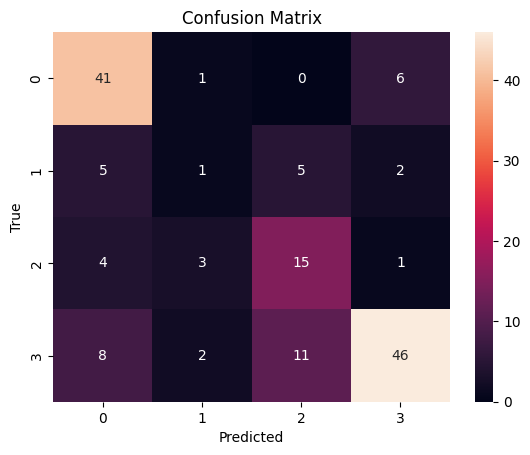

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import numpy as np
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import copy

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

NUM_CLASSES = 4

# ---- ViT Model ----
def make_vit(num_classes=4):
    m = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
    m.heads.head = nn.Linear(m.heads.head.in_features, num_classes)
    return m

# ---- Setup ----
MODEL_NAME      = "vit_b_16"
EXPERIMENT_NAME = f"{MODEL_NAME}_weighted_True"

model = make_vit(NUM_CLASSES).to(device)

# ---- Class Weights ----
counts = Counter(y_train)
total  = sum(counts.values())

class_weights = torch.tensor(
    [total / counts.get(i, 1) for i in range(NUM_CLASSES)],
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# ---- Train/Eval loop ----
def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()

    losses, all_preds, all_true = [], [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        with torch.set_grad_enabled(train):
            logits = model(imgs)
            loss = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        losses.append(loss.item())

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_true.extend(labels.detach().cpu().numpy())

    return float(np.mean(losses)), np.array(all_true), np.array(all_preds)

# ---- Training ----
EPOCHS = 10
PATIENCE = 3   # early stopping

best_f1 = 0
patience_counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

history = {"val_acc": [], "val_f1": []}

print(f"\nTraining: {MODEL_NAME}")
print("=" * 55)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_y, tr_p = run_epoch(model, train_loader, train=True)
    va_loss, va_y, va_p = run_epoch(model, val_loader, train=False)

    scheduler.step()

    tr_acc = accuracy_score(tr_y, tr_p)
    va_acc = accuracy_score(va_y, va_p)
    va_f1  = f1_score(va_y, va_p, average="macro")

    history["val_acc"].append(va_acc)
    history["val_f1"].append(va_f1)

    print(f"Epoch {epoch:02d} | "
          f"train acc {tr_acc:.3f} | "
          f"val acc {va_acc:.3f} | "
          f"val macroF1 {va_f1:.3f}")

    # ---- Early Stopping ----
    if va_f1 > best_f1:
        best_f1 = va_f1
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print("\n⛔ Early stopping triggered!")
        break

# ---- Load Best Model ----
model.load_state_dict(best_model_wts)

# ---- Final Evaluation ----
_, va_y, va_p = run_epoch(model, val_loader, train=False)

final_acc = accuracy_score(va_y, va_p)
final_f1  = f1_score(va_y, va_p, average="macro")
cm        = confusion_matrix(va_y, va_p)

# ---- Save results ----
if "experiment_results" not in globals():
    experiment_results = {}

experiment_results[EXPERIMENT_NAME] = {
    "final_val_acc": final_acc,
    "final_val_f1": final_f1,
    "confusion_matrix": cm,
    "history": history
}

# ---- Print Results ----
print("\n✅ Training Completed:", EXPERIMENT_NAME)
print("Final Val Accuracy :", round(final_acc, 3))
print("Final Val MacroF1  :", round(final_f1, 3))
print("\nConfusion Matrix:\n", cm)

# ---- Optional: Plot confusion matrix ----
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

### **CLIP** : Weak Result. we will not include it.

In [29]:


import torch
import torch.nn as nn
import torch.optim as optim
import open_clip
import numpy as np
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

NUM_CLASSES = 4

# ---- CLIP Model ----
class CLIPClassifier(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        # Load CLIP image encoder
        self.clip_model, _, self.preprocess = open_clip.create_model_and_transforms(
            "ViT-B-32", pretrained="openai"
        )
        # Freeze CLIP backbone
        for param in self.clip_model.parameters():
            param.requires_grad = False

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        with torch.no_grad():
            features = self.clip_model.encode_image(x)
        features = features.float()
        return self.classifier(features)

# ---- Setup ----
MODEL_NAME      = "clip_vit_b32"
EXPERIMENT_NAME = f"{MODEL_NAME}_weighted_True"

model = CLIPClassifier(NUM_CLASSES).to(device)

# Class weights
counts        = Counter(y_train)
total         = sum(counts.values())
class_weights = torch.tensor(
    [total / (counts.get(i, 1)) for i in range(NUM_CLASSES)],
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)


optimizer = optim.AdamW(
    model.classifier.parameters(), lr=1e-3, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# ---- Train/Eval loop ----
def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()
    losses, all_preds, all_true = [], [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        with torch.set_grad_enabled(train):
            logits = model(imgs)
            loss   = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        losses.append(loss.item())
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_true.extend(labels.detach().cpu().numpy())

    return float(np.mean(losses)), np.array(all_true), np.array(all_preds)

# ---- Training ----
EPOCHS  = 10
history = {"val_acc": [], "val_f1": []}

print(f"\nTraining: {MODEL_NAME}")
print("=" * 55)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_y, tr_p = run_epoch(model, train_loader, train=True)
    va_loss, va_y, va_p = run_epoch(model, val_loader,   train=False)
    scheduler.step()

    tr_acc = accuracy_score(tr_y, tr_p)
    va_acc = accuracy_score(va_y, va_p)
    va_f1  = f1_score(va_y, va_p, average="macro")

    history["val_acc"].append(va_acc)
    history["val_f1"].append(va_f1)

    print(f"Epoch {epoch:02d} | "
          f"train acc {tr_acc:.3f} | "
          f"val acc {va_acc:.3f} | "
          f"val macroF1 {va_f1:.3f}")

cm = confusion_matrix(va_y, va_p)

# Save results
if "experiment_results" not in globals():
    experiment_results = {}

experiment_results[EXPERIMENT_NAME] = {
    "final_val_acc"   : history["val_acc"][-1],
    "final_val_f1"    : history["val_f1"][-1],
    "confusion_matrix": cm,
    "history"         : history
}

print("\n✅ Saved:", EXPERIMENT_NAME)
print("Final Val Accuracy :", round(history["val_acc"][-1], 3))
print("Final Val MacroF1  :", round(history["val_f1"][-1],  3))
print("Confusion Matrix:\n", cm)

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(



Training: clip_vit_b32
Epoch 01 | train acc 0.400 | val acc 0.530 | val macroF1 0.456
Epoch 02 | train acc 0.510 | val acc 0.556 | val macroF1 0.472
Epoch 03 | train acc 0.557 | val acc 0.543 | val macroF1 0.459
Epoch 04 | train acc 0.578 | val acc 0.530 | val macroF1 0.490
Epoch 05 | train acc 0.577 | val acc 0.596 | val macroF1 0.501
Epoch 06 | train acc 0.567 | val acc 0.530 | val macroF1 0.468
Epoch 07 | train acc 0.602 | val acc 0.510 | val macroF1 0.473
Epoch 08 | train acc 0.575 | val acc 0.563 | val macroF1 0.497
Epoch 09 | train acc 0.613 | val acc 0.543 | val macroF1 0.484
Epoch 10 | train acc 0.600 | val acc 0.550 | val macroF1 0.489

✅ Saved: clip_vit_b32_weighted_True
Final Val Accuracy : 0.55
Final Val MacroF1  : 0.489
Confusion Matrix:
 [[30  7  2  9]
 [ 2  4  6  1]
 [ 6  3 13  1]
 [15  8  8 36]]


### Pre and post disaster change based analysis

In [33]:
import os, json, glob
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as T
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from collections import Counter
import rasterio

device = "cuda" if torch.cuda.is_available() else "cpu"

NUM_CLASSES = 4
SEVERITY_ORDER = {"no-damage":0, "minor-damage":1, "major-damage":2, "destroyed":3}

# =========================
# DATASET
# =========================
class PrePostDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def load_tif(self, path):
        try:
            with rasterio.open(path) as src:
                img = src.read([1,2,3]).transpose(1,2,0).astype(np.float32)
                img = img / 255.0
        except:
            img = np.zeros((224,224,3), dtype=np.float32)
        return img

    def __getitem__(self, idx):
        pre_path, post_path, label = self.samples[idx]

        pre_img = self.load_tif(pre_path)
        post_img = self.load_tif(post_path)

        from PIL import Image
        pre_img = Image.fromarray((pre_img*255).astype(np.uint8))
        post_img = Image.fromarray((post_img*255).astype(np.uint8))

        if self.transform:
            pre_img = self.transform(pre_img)
            post_img = self.transform(post_img)

        return pre_img, post_img, torch.tensor(label)

# =========================
# BUILD SAMPLES (FIXED) - Corrected Logic
# =========================
samples = []

# Assuming IMG_DIR and LBL_DIR are defined from previous cells
# IMG_DIR = "/content/xview2_part_aa/geotiffs/hold/images"
# LBL_DIR = "/content/xview2_part_aa/geotiffs/hold/labels"

for post_path in glob.glob(os.path.join(IMG_DIR, "*_post_disaster.tif")):
    pre_path = post_path.replace("_post_disaster", "_pre_disaster")

    if not os.path.exists(pre_path):
        continue

    # Extract base_id for JSON lookup
    base_id = os.path.basename(post_path).replace("_post_disaster.tif", "") + "_post_disaster"
    json_path = os.path.join(LBL_DIR, base_id + ".json")

    if not os.path.exists(json_path):
        continue

    with open(json_path) as f:
        data = json.load(f)

    # Initialize dmg_list for the current JSON
    dmg_list = []

    # Safely extract features
    features = data.get("features", {})
    if isinstance(features, dict):
        feats = features.get("xy", [])
    elif isinstance(features, list):
        feats = features
    else:
        feats = []

    for feat in feats:
        if not isinstance(feat, dict):
            continue

        props = feat.get("properties", {})
        if not isinstance(props, dict):
            continue

        dmg = props.get("subtype") or props.get("damage_type")

        if dmg in SEVERITY_ORDER:
            dmg_list.append(dmg)

    # Only add sample if valid damage labels were found
    if dmg_list:
        label = SEVERITY_ORDER[max(dmg_list, key=lambda x: SEVERITY_ORDER[x])]
        samples.append((pre_path, post_path, label))
    else:
        # If no valid damage labels, skip this image
        pass

print("Total samples:", len(samples))

# =========================
# SPLIT
# =========================
labels = [s[2] for s in samples]

# Handle case where `samples` might be empty after filtering
if not samples:
    print("Warning: No valid samples found for training. Skipping training.")
    train_s, val_s = [], []
    train_loader = DataLoader([], batch_size=16) # Empty DataLoader
    val_loader = DataLoader([], batch_size=16) # Empty DataLoader
else:
    train_s, val_s = train_test_split(samples, test_size=0.2, stratify=labels, random_state=42)

    # =========================
    # TRANSFORMS
    # =========================
    tfm = T.Compose([
        T.Resize((224,224)),
        T.RandomHorizontalFlip(),
        T.RandomRotation(15),
        T.ToTensor(),
        T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])

    train_loader = DataLoader(PrePostDataset(train_s, tfm), batch_size=16, shuffle=True)
    val_loader   = DataLoader(PrePostDataset(val_s, tfm), batch_size=16)


# =========================
# BEST MODEL (ATTENTION SIAMESE)
# =========================
class AttentionFusion(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(dim * 2, dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.Sigmoid()
        )

    def forward(self, f_pre, f_post):
        attn_weights = self.attn(torch.cat([f_pre, f_post], dim=1))
        fused = attn_weights * f_post + (1 - attn_weights) * f_pre
        return fused


class BestSiameseNet(nn.Module):
    def __init__(self):
        super().__init__()

        backbone = models.mobilenet_v3_large(weights="IMAGENET1K_V1")
        self.encoder = nn.Sequential(*list(backbone.children())[:-1])
        feat_dim = 960  # mobilenet_v3_large output

        # 🔥 Partial fine-tuning (VERY IMPORTANT)
        for name, param in self.encoder.named_parameters():
            if "features.12" in name or "features.13" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False

        self.fusion = AttentionFusion(feat_dim)

        self.classifier = nn.Sequential(
            nn.Linear(feat_dim * 2, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, NUM_CLASSES)
        )

    def encode(self, x):
        f = self.encoder(x)
        return torch.flatten(f, 1)

    def forward(self, pre, post):
        f_pre = self.encode(pre)
        f_post = self.encode(post)

        diff = torch.abs(f_post - f_pre)

        fused = self.fusion(f_pre, f_post)

        # 🔥 FINAL COMBINATION (very important)
        combined = torch.cat([fused, diff], dim=1)

        return self.classifier(combined)


model = BestSiameseNet().to(device)

# =========================
# TRAINING (FIXED)
# =========================
if not train_s:
    print("Skipping training as no samples were available.")
else:
    # ---- Class weights ----
    counts = Counter([s[2] for s in train_s])
    weights = torch.tensor(
        [len(train_s) / counts.get(i,1) for i in range(NUM_CLASSES)],
        dtype=torch.float32
    ).to(device)

    # ---- Loss + Optimizer ----
    criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

    # ---- Run function ----
    def run(loader, train=True):
        model.train() if train else model.eval()
        preds, trues = [], []

        for pre, post, y in loader:
            pre, post, y = pre.to(device), post.to(device), y.to(device)

            out = model(pre, post)
            loss = criterion(out, y)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(y.cpu().numpy())

        return trues, preds

    # ---- Training Loop ----
    EPOCHS = 20

    for epoch in range(EPOCHS):
        run(train_loader, True)
        y, p = run(val_loader, False)

        scheduler.step()

        print(f"Epoch {epoch+1:02d} | "
              f"Acc: {accuracy_score(y,p):.3f} | "
              f"F1: {f1_score(y,p,average='macro'):.3f}")

    # ---- FINAL EVALUATION ----
    y, p = run(val_loader, False)

    print("\n✅ FINAL RESULTS")
    print("Accuracy :", round(accuracy_score(y,p),3))
    print("Macro F1 :", round(f1_score(y,p,average='macro'),3))

    print("\nConfusion Matrix:\n", confusion_matrix(y,p))


Total samples: 751
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 178MB/s]


Epoch 01 | Acc: 0.411 | F1: 0.312
Epoch 02 | Acc: 0.490 | F1: 0.444
Epoch 03 | Acc: 0.530 | F1: 0.479
Epoch 04 | Acc: 0.556 | F1: 0.495
Epoch 05 | Acc: 0.556 | F1: 0.500
Epoch 06 | Acc: 0.550 | F1: 0.502
Epoch 07 | Acc: 0.550 | F1: 0.479
Epoch 08 | Acc: 0.563 | F1: 0.510
Epoch 09 | Acc: 0.556 | F1: 0.467
Epoch 10 | Acc: 0.543 | F1: 0.476
Epoch 11 | Acc: 0.563 | F1: 0.487
Epoch 12 | Acc: 0.550 | F1: 0.461
Epoch 13 | Acc: 0.543 | F1: 0.453
Epoch 14 | Acc: 0.576 | F1: 0.500
Epoch 15 | Acc: 0.556 | F1: 0.482
Epoch 16 | Acc: 0.570 | F1: 0.498
Epoch 17 | Acc: 0.543 | F1: 0.463
Epoch 18 | Acc: 0.530 | F1: 0.480
Epoch 19 | Acc: 0.563 | F1: 0.498
Epoch 20 | Acc: 0.523 | F1: 0.450

✅ FINAL RESULTS
Accuracy : 0.609
Macro F1 : 0.534

Confusion Matrix:
 [[29  2  9  8]
 [ 4  4  2  3]
 [ 3  4 15  1]
 [ 6  5 12 44]]
